In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split  # Split data into train & test
from sklearn.preprocessing import LabelEncoder,StandardScaler  # Data preprocessing
from sklearn.linear_model import LinearRegression  # ML Model
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score  # Evaluation metrics


In [3]:
df = pd.read_csv("car data.csv")

In [4]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [6]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(2)

In [8]:
df.drop_duplicates()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [9]:
le = LabelEncoder()

In [10]:
df["Fuel_Type ="] = le.fit_transform(df["Fuel_Type"]) # Petrol/Diesel
df["Selling_type"] = le.fit_transform(df["Selling_type"]) # Dealer/Individual
df["Transmission"] = le.fit_transform(df["Transmission"])  # Manual/Automatic

In [11]:
categorical_cols = ["Fuel_Type","Selling_type","Transmission","Car_Name"]

for col in categorical_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

In [12]:
df["Car_Age"] = 2024 - df["Year"]

In [13]:
df["Car_Age"]

0      10
1      11
2       7
3      13
4      10
       ..
296     8
297     9
298    15
299     7
300     8
Name: Car_Age, Length: 301, dtype: int64

In [14]:
df = df.drop("Year",axis = 1)

In [15]:
X = df.drop("Selling_Price",axis=1)  # Input features
y = df["Selling_Price"]   # Target (price)

In [16]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.3 , random_state = 43)

In [17]:
model = LinearRegression()  # create model
model.fit(X_train,y_train)  # train model

LinearRegression()

In [18]:
y_pred = model.predict(X_test) 

r2 = r2_score(y_test,y_pred)

print("\nModel R2 Score:",r2)


Model R2 Score: 0.8385268693020079


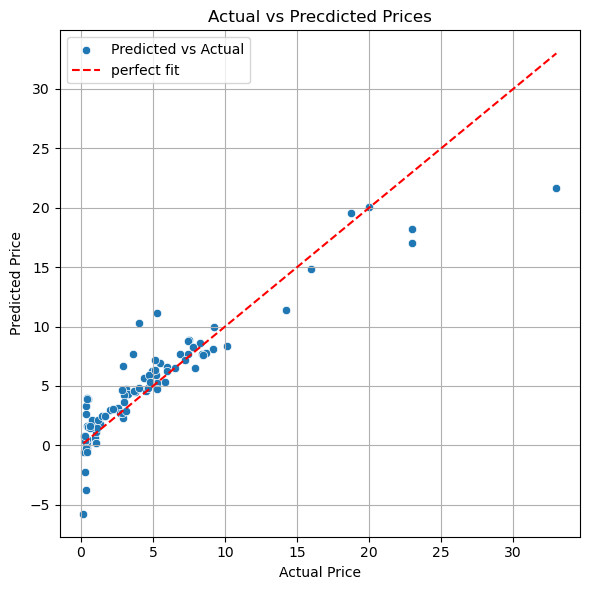

In [19]:
plt.figure(figsize = (6,6))
sns.scatterplot(x = y_test, y = y_pred , label = "Predicted vs Actual")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Precdicted Prices")
plt.plot([y_test.min(),y_test.max()],
        [y_test.min(),y_test.max()],'r--',label="perfect fit")
plt.tight_layout()
plt.grid()
plt.legend()